# 🧠 Semantic Spotter (Insurance PDFs)
## Deep PDF Structure Analysis → Smart Chunking → LlamaIndex RAG (Spotter Mode)

This notebook is **evaluation-ready** and **report-friendly**.

### ✅ What you get end-to-end
1. Layout-aware PDF extraction (line-by-line with coordinates)
2. Header/Footer noise detection & removal
3. TOC, headings, tables and indentation analysis
4. Auto-selected chunking strategy (section-aware)
5. Vector index (persistent) + optional summary index
6. Spotter Mode (high precision):
   - Top-K retrieval
   - Similarity cutoff filtering
   - "Not found in documents" guardrail
   - Citations: file + page range + section
7.  Chunk Viewer + Interactive Search Inspector
8.  RouterQueryEngine (Summary vs Lookup)
9.  Auto-export report-ready flowchart (Mermaid + Graphviz)

---


## 📌 Notebook Navigation

1. Project Overview & Goals  
2. Dataset Understanding (Insurance PDFs)  
3. Why LlamaIndex (and why Spotter Mode)  
4. PDF Structure Analysis Methodology  
5. Chunking Strategy (Decision + Rationale)  
6. Indexing & Retrieval Design  
7. [A] Chunk Viewer + Search Inspector  
8. [B] RouterQueryEngine (Summary vs Lookup)  
9. [C] Guardrails ("Not found")  
10. [D] Flowchart Export  
11. Evaluation Queries  
12. Submission Artifacts + Troubleshooting  

---


# 🎯 Project Overview & Problem Statement

## Problem Statement
Insurance policy PDFs are long, sectioned documents containing:
- Definitions, exclusions, benefits, eligibility, schedules
- Repeated headers/footers and page artifacts
- Tables with critical schedule details

A naïve PDF-to-text → fixed-size chunking causes:
- noisy retrieval (headers/footers appear everywhere)
- mixed context (chunks cross clauses)
- reduced precision (wrong sections retrieved)
- hallucinations (answers without strong evidence)

## Objective
Build a **Semantic Spotter** system that:
- retrieves only **high-confidence evidence**
- provides **citations** (file + page + section)
- returns **"Not found"** when evidence is weak
- supports both **lookup** and **summary** questions via routing

---


# 0) 🔧 Setup & Installation (Optional)

If your environment is fresh, install dependencies below.
If already installed, skip.

---


In [1]:
# Uncomment if needed:
%pip install -U pdfplumber pymupdf pandas numpy matplotlib
%pip install -U llama-index llama-index-llms-openai llama-index-embeddings-openai
%pip install -U sentence-transformers llama-index-embeddings-huggingface
%pip install -U ipywidgets graphviz
%pip install Pillow==11.3.0 --force-reinstall

print("✅ Setup cell ready (install lines are commented).")

  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.4 MB)
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.3
    Uninstalling pandas-2.2.3:
      Successfully uninstalled pandas-2.2.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
llama-index-readers-file 0.5.5 requires pandas<2.3.0, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
  Using cached pandas-2.2.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (89 kB)
Using cached pandas-2.2.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.7 MB)
  Attempting uninstall: pandas
    Found existing installation: pandas 2.3.3
 

# 1) ⚙️ Configuration

### Modes
- **Mode A (Full RAG):** set `OPENAI_API_KEY` → Answer + citations  
- **Mode B (Retrieval-only):** no key → Evidence-only (still valid for Spotter evaluation)

### Recommended folders (evaluation-friendly)
- PDFs: `data/pdfs/*.pdf`
- Analysis JSONs: `outputs/pdf_analysis/`
- Persisted index: `storage_llamaindex/`
- Report artifacts: `outputs/report_artifacts/`

---


In [2]:
import logging
import sys

logging.basicConfig(
    level=logging.INFO,  # ✅ show INFO
    stream=sys.stdout,   # ✅ print to terminal
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    force=True,          # ✅ override any prior logging config (very useful in notebooks/apps)
)

logger = logging.getLogger(__name__)

In [3]:
from __future__ import annotations

import os
import re
import json
import math
import statistics
import logging
from dataclasses import dataclass
from pathlib import Path
from collections import Counter, defaultdict
from typing import Any, Dict, List, Tuple, Optional

from IPython.display import display

# -----------------------------------------------------------------------------
# Logging
# -----------------------------------------------------------------------------
# Why logging?
# - Helps evaluation & debugging (what step ran, how many chunks, etc.)
# - Easier than scattered prints once notebook gets large
# -----------------------------------------------------------------------------
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger("semantic_spotter")

# -----------------------------------------------------------------------------
# Paths
# -----------------------------------------------------------------------------
PDF_DIR_PRIMARY = Path("data/pdfs")     # preferred for evaluation
PDF_DIR_FALLBACK = Path("/mnt/data")    # fallback for hosted setups
PDF_DIR_PRIMARY.mkdir(parents=True, exist_ok=True)

OUT_DIR = Path("outputs/pdf_analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

PERSIST_DIR = Path("storage_llamaindex")
PERSIST_DIR.mkdir(parents=True, exist_ok=True)

REPORT_DIR = Path("outputs/report_artifacts")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Header/Footer detection parameters
# -----------------------------------------------------------------------------
REPEAT_FRACTION = 0.70   # line appears on >=70% pages -> header/footer candidate
TOP_BAND_FRAC = 0.12     # top region of page considered header zone
BOT_BAND_FRAC = 0.12     # bottom region of page considered footer zone

# -----------------------------------------------------------------------------
# TOC detection
# -----------------------------------------------------------------------------
TOC_SCAN_PAGES = 10      # TOC usually appears early

# -----------------------------------------------------------------------------
# Chunking defaults
# -----------------------------------------------------------------------------
# General chunks are larger; definitions are smaller for higher precision.
DEFAULT_TARGET_CHARS = 2400
DEFAULT_OVERLAP_CHARS = 300
DEFN_TARGET_CHARS = 1400
DEFN_OVERLAP_CHARS = 220

# -----------------------------------------------------------------------------
# Spotter retrieval settings
# -----------------------------------------------------------------------------
TOP_K = 6
SIMILARITY_CUTOFF = 0.80  # raise => more precision, lower => more recall

logger.info("✅ Config loaded")
logger.info(f"PDF_DIR_PRIMARY: {PDF_DIR_PRIMARY.resolve()}")
logger.info(f"OUT_DIR: {OUT_DIR.resolve()}")
logger.info(f"PERSIST_DIR: {PERSIST_DIR.resolve()}")
logger.info(f"REPORT_DIR: {REPORT_DIR.resolve()}")

2025-12-18 08:53:05,233 | INFO | semantic_spotter | ✅ Config loaded
2025-12-18 08:53:05,233 | INFO | semantic_spotter | PDF_DIR_PRIMARY: /content/data/pdfs
2025-12-18 08:53:05,234 | INFO | semantic_spotter | OUT_DIR: /content/outputs/pdf_analysis
2025-12-18 08:53:05,235 | INFO | semantic_spotter | PERSIST_DIR: /content/storage_llamaindex
2025-12-18 08:53:05,235 | INFO | semantic_spotter | REPORT_DIR: /content/outputs/report_artifacts


# 2) 📦 Discover PDFs

We search PDFs in:
1. `data/pdfs/` (recommended)
2. `/mnt/data/` (fallback)

---


In [4]:
def discover_pdfs() -> List[Path]:
    """
    Discover PDFs to process.

    Search order:
    1) data/pdfs/*.pdf (recommended for evaluation submissions)
    2) /mnt/data/*.pdf (fallback for hosted environments)

    Returns
    -------
    List[Path]
        Sorted list of PDF file paths.

    Raises
    ------
    FileNotFoundError
        If no PDFs are found in either location.
    """
    if PDF_DIR_PRIMARY.exists():
        pdfs = sorted(PDF_DIR_PRIMARY.glob("*.pdf"))
        if pdfs:
            return pdfs

    if PDF_DIR_FALLBACK.exists():
        pdfs = sorted(PDF_DIR_FALLBACK.glob("*.pdf"))
        if pdfs:
            return pdfs

    raise FileNotFoundError(
        "No PDFs found.\n"
        f"- Put PDFs in: {PDF_DIR_PRIMARY.resolve()} OR\n"
        f"- Ensure PDFs exist in: {PDF_DIR_FALLBACK.resolve()}"
    )


PDFS = discover_pdfs()
logger.info(f"✅ Found {len(PDFS)} PDFs")
for p in PDFS:
    logger.info(f" - {p.name}")

2025-12-18 08:53:05,242 | INFO | semantic_spotter | ✅ Found 8 PDFs
2025-12-18 08:53:05,243 | INFO | semantic_spotter |  - HDFC-Life-Easy-Health-101N110V03-Policy-Bond-Single-Pay.pdf
2025-12-18 08:53:05,243 | INFO | semantic_spotter |  - HDFC-Life-Group-Poorna-Suraksha-101N137V02-Policy-Document.pdf
2025-12-18 08:53:05,244 | INFO | semantic_spotter |  - HDFC-Life-Group-Term-Life-Policy.pdf
2025-12-18 08:53:05,244 | INFO | semantic_spotter |  - HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-Document (1).pdf
2025-12-18 08:53:05,245 | INFO | semantic_spotter |  - HDFC-Life-Sanchay-Plus-Life-Long-Income-Option-101N134V19-Policy-Document.pdf
2025-12-18 08:53:05,245 | INFO | semantic_spotter |  - HDFC-Life-Smart-Pension-Plan-Policy-Document-Online.pdf
2025-12-18 08:53:05,245 | INFO | semantic_spotter |  - HDFC-Surgicare-Plan-101N043V01.pdf
2025-12-18 08:53:05,246 | INFO | semantic_spotter |  - Principal-Sample-Life-Insurance-Policy.pdf


# 3) 🔍 PDF Extraction (Line-by-line, Layout-aware)

We **do not** treat a PDF as plain text.

Instead, we extract **lines with coordinates**:
- `top/bottom` (vertical position)
- `x0/x1` (horizontal alignment)
- `page number`

### Why this matters
- Detect and remove **headers/footers** (position + repetition)
- Identify **indentation clusters** (bullets/definitions vs normal text)
- Preserve **tables** as separate chunks for schedule retrieval

---


In [5]:
import pdfplumber

try:
    import fitz  # PyMuPDF (optional page preview)
    HAVE_PYMUPDF = True
except Exception:
    HAVE_PYMUPDF = False


def _collapse_ws(s: str) -> str:
    """Collapse internal whitespace and strip."""
    return re.sub(r"\s+", " ", s.strip())


def normalize_for_repeat(s: str) -> str:
    """
    Normalize lines for repetition detection.

    Why?
    - Headers/footers repeat but include changing numbers (page X of Y)
    - Normalization makes them match across pages
    """
    s = _collapse_ws(s).lower()
    s = re.sub(r"\bpage\s*\d+\s*(of\s*\d+)?\b", "page #", s, flags=re.I)
    s = re.sub(r"\bp\s*a\s*g\s*e\s*\|\s*\d+\b", "page | #", s, flags=re.I)
    s = re.sub(r"\b\d{1,4}\b", "#", s)
    return s


@dataclass
class Line:
    """A single extracted 'line' with layout metadata."""
    text: str
    page: int
    top: float
    bottom: float
    x0: float
    x1: float


def extract_lines_pdfplumber(page) -> List[Line]:
    """
    Extract lines by grouping words that share similar vertical positions.

    Notes
    -----
    pdfplumber returns word-level boxes. We group by 'top' coordinate into
    small buckets to rebuild lines.

    Returns
    -------
    List[Line]
        Ordered lines with coordinates.
    """
    words = page.extract_words(use_text_flow=True, keep_blank_chars=False)
    if not words:
        return []

    bucket = 3.0  # smaller bucket => tighter grouping
    groups: Dict[int, List[dict]] = defaultdict(list)

    for w in words:
        key = int(round(float(w["top"]) / bucket))
        groups[key].append(w)

    lines: List[Line] = []
    for key in sorted(groups.keys()):
        ws = sorted(groups[key], key=lambda x: float(x["x0"]))
        text = " ".join(_collapse_ws(w["text"]) for w in ws if _collapse_ws(w["text"]))
        if not text:
            continue

        x0 = min(float(w["x0"]) for w in ws)
        x1 = max(float(w["x1"]) for w in ws)
        top = min(float(w["top"]) for w in ws)
        bottom = max(float(w["bottom"]) for w in ws)

        lines.append(Line(text=text, page=int(page.page_number), top=top, bottom=bottom, x0=x0, x1=x1))

    return lines


def try_extract_tables(page) -> List[List[List[str]]]:
    """
    Best-effort table extraction (schedules often appear as tables).

    Returns
    -------
    list of tables (each is list of rows, each row list of cells)
    """
    try:
        settings = {
            "vertical_strategy": "lines",
            "horizontal_strategy": "lines",
            "intersection_tolerance": 5,
            "snap_tolerance": 3,
            "join_tolerance": 3,
            "edge_min_length": 10,
            "min_words_vertical": 1,
            "min_words_horizontal": 1,
        }
        tables = page.extract_tables(table_settings=settings)
        # keep only non-empty tables
        return [t for t in tables if t and any(any((c or "").strip() for c in row) for row in t)]
    except Exception:
        return []


logger.info("✅ Extractors ready")

2025-12-18 08:53:05,383 | INFO | semantic_spotter | ✅ Extractors ready


# 4) 🧩 Structure Detectors

We detect:
- **Headings / section boundaries**
- **TOC pages**
- **Noise lines** (page artifacts)

These signals directly influence chunking.

---


In [6]:
# Heading patterns tuned for insurance policy documents
HEADING_PATTERNS = [
    re.compile(r"^\s*part\s+[a-z]\b", re.I),
    re.compile(r"^\s*[a-z]\.\d+(\.\d+)?\b", re.I),
    re.compile(r"^\s*\d+(\.\d+)*\s*[A-Za-z].{0,80}$"),
    re.compile(r"^\s*policy\s+schedule\b", re.I),
    re.compile(r"^\s*definitions?\b", re.I),
    re.compile(r"^\s*table\s+of\s+contents\b", re.I),
]


def looks_like_heading(line: str) -> bool:
    """
    Heuristic heading detector.

    Strategy:
    - regex patterns for typical headings (Part A, 1.2, Definitions, Policy Schedule)
    - fallback heuristic: short line, mostly uppercase (common in titles)
    """
    s = _collapse_ws(line)
    if not s:
        return False
    if any(p.search(s) for p in HEADING_PATTERNS):
        return True

    alpha = sum(ch.isalpha() for ch in s)
    upper = sum(ch.isupper() for ch in s)
    digits = sum(ch.isdigit() for ch in s)

    if 5 <= len(s) <= 90 and alpha >= 5:
        if upper / max(alpha, 1) > 0.75 and digits / max(len(s), 1) < 0.25:
            return True
    return False


def looks_like_toc_line(line: str) -> bool:
    """
    Detect TOC-like lines.

    Common TOC patterns:
    - dot leaders ending with a page number: 'Section ..... 12'
    - text ending with a trailing number in early pages
    """
    s = _collapse_ws(line)
    if not s:
        return False
    if re.search(r"\.{3,}\s*\d+\s*$", s):
        return True
    if re.search(r"\s+\d+\s*$", s) and len(s) > 12 and "page" not in s.lower():
        return True
    return False


def is_noise_line(line: str) -> bool:
    """
    Identify lines that are almost certainly noise.
    Examples:
    - 'Page 3 of 12'
    - 'This page left blank intentionally'
    """
    s = _collapse_ws(line)
    if not s:
        return True
    if re.match(r"^page\s*\d+\s*(of\s*\d+)?$", s, flags=re.I):
        return True
    if re.search(r"\bp\s*a\s*g\s*e\s*\|\s*\d+\b", s, flags=re.I):
        return True
    if re.match(r"^this page left blank intentionally$", s, flags=re.I):
        return True
    return False


logger.info("✅ Detectors ready")

2025-12-18 08:53:05,398 | INFO | semantic_spotter | ✅ Detectors ready


# 5) 📊 PDF Analyzer (Detailed Structure Study)

For each PDF, we compute:
- repeated **headers/footers** (layout + frequency)
- **TOC pages**
- pages with **tables**
- sample **headings**
- indentation clusters (layout signal)
- recommended chunking configuration

Artifacts saved:
- `outputs/pdf_analysis/<pdf>__analysis.json`
- `outputs/pdf_analysis/ALL_PDFS__analysis_summary.json`

---


In [7]:
def _kmeans_1d(values: List[float], k: int = 2, iters: int = 20) -> Tuple[List[float], List[int]]:
    """
    Minimal 1D k-means to detect indentation clusters.

    Why?
    - Many PDFs contain two major indentation modes:
      body text vs bullet/definition blocks.
    """
    if not values:
        return [], []
    if k <= 1:
        c = [statistics.median(values)]
        return c, [0] * len(values)

    vmin, vmax = min(values), max(values)
    centers = [vmin + (vmax - vmin) * i / (k - 1) for i in range(k)]
    labels = [0] * len(values)

    for _ in range(iters):
        # Assign each point to the nearest center
        for i, v in enumerate(values):
            labels[i] = min(range(k), key=lambda j: abs(v - centers[j]))

        # Recompute centers
        new_centers = []
        for j in range(k):
            cluster = [values[i] for i in range(len(values)) if labels[i] == j]
            new_centers.append(sum(cluster) / len(cluster) if cluster else centers[j])

        # Converged?
        if all(abs(new_centers[j] - centers[j]) < 1e-6 for j in range(k)):
            break

        centers = new_centers

    return centers, labels


def analyze_pdf(pdf_path: Path) -> Dict[str, Any]:
    """
    Analyze a PDF's structure for robust chunking.

    Returns
    -------
    Dict[str, Any]
        A JSON-serializable report with:
        - header/footer candidates
        - toc pages
        - table pages
        - heading samples
        - alignment + indentation info
        - recommended chunking configuration
    """
    report: Dict[str, Any] = {
        "pdf": pdf_path.name,
        "pages": 0,
        "page_sizes": [],
        "header_candidates": [],
        "footer_candidates": [],
        "toc_pages": [],
        "table_pages": [],
        "heading_samples": [],
        "alignment": {},
        "indent_clusters": {},
        "recommended_chunking": {},
    }

    with pdfplumber.open(str(pdf_path)) as pdf:
        report["pages"] = len(pdf.pages)

        header_norm_counts = Counter()
        footer_norm_counts = Counter()
        x0_samples: List[float] = []
        all_page_lines: Dict[int, List[Line]] = {}

        # Pass 1: collect repeated header/footer candidates
        for page in pdf.pages:
            w, h = float(page.width), float(page.height)
            report["page_sizes"].append({"page": page.page_number, "width": w, "height": h})

            lines = extract_lines_pdfplumber(page)
            all_page_lines[int(page.page_number)] = lines

            for ln in lines:
                if len(ln.text) >= 25:
                    x0_samples.append(ln.x0)

                n = normalize_for_repeat(ln.text)
                if ln.top <= h * TOP_BAND_FRAC and len(n) >= 6:
                    header_norm_counts[n] += 1
                if ln.bottom >= h * (1 - BOT_BAND_FRAC) and len(n) >= 6:
                    footer_norm_counts[n] += 1

        min_repeat = max(2, math.ceil(report["pages"] * REPEAT_FRACTION))
        header_set = {k for k, v in header_norm_counts.items() if v >= min_repeat}
        footer_set = {k for k, v in footer_norm_counts.items() if v >= min_repeat}

        report["header_candidates"] = sorted(
            [{"line_norm": k, "count": header_norm_counts[k]} for k in header_set],
            key=lambda x: -x["count"],
        )
        report["footer_candidates"] = sorted(
            [{"line_norm": k, "count": footer_norm_counts[k]} for k in footer_set],
            key=lambda x: -x["count"],
        )

        # Pass 2: TOC, headings, tables, indentation profile
        heading_samples: List[Dict[str, Any]] = []
        toc_pages: List[int] = []
        table_pages: List[Dict[str, Any]] = []
        indent_values: List[float] = []

        for page in pdf.pages:
            pno = int(page.page_number)
            lines = all_page_lines[pno]

            # TOC detection
            toc_hits = 0
            for ln in lines:
                t = ln.text.lower()
                if "table of contents" in t:
                    toc_hits += 3
                if looks_like_toc_line(ln.text):
                    toc_hits += 1
            toc_ratio = toc_hits / max(1, len(lines))

            if (pno <= TOC_SCAN_PAGES and toc_ratio >= 0.20) or any("table of contents" in l.text.lower() for l in lines):
                toc_pages.append(pno)

            # heading samples
            for ln in lines:
                if looks_like_heading(ln.text):
                    heading_samples.append({"page": pno, "text": _collapse_ws(ln.text)[:140]})

            # table detection
            tables = try_extract_tables(page)
            if tables:
                table_pages.append({"page": pno, "tables": len(tables)})

            # indentation sampling
            for ln in lines:
                if len(ln.text) >= 30:
                    indent_values.append(ln.x0)

        report["toc_pages"] = sorted(set(toc_pages))
        report["table_pages"] = table_pages
        report["heading_samples"] = heading_samples[:60]

        if x0_samples:
            report["alignment"] = {
                "x0_min": min(x0_samples),
                "x0_max": max(x0_samples),
                "x0_median": statistics.median(x0_samples),
                "x0_stdev": statistics.pstdev(x0_samples) if len(x0_samples) > 1 else 0.0,
                "hint": "Lower stdev => consistent left alignment; higher => indents/tables/multi-layout.",
            }

        if indent_values:
            centers, _ = _kmeans_1d(indent_values, k=2)
            if centers:
                cs = sorted(centers)
                report["indent_clusters"] = {
                    "centers": cs,
                    "gap": (cs[1] - cs[0]) if len(cs) > 1 else 0.0,
                    "note": "Large gap suggests indented bullets/blocks; section-aware chunking recommended.",
                }

        # Recommend chunking
        heading_density = len(heading_samples) / max(1, report["pages"])
        has_toc = len(report["toc_pages"]) > 0
        has_tables = len(report["table_pages"]) > 0

        strategy = "section_aware" if heading_density >= 1.0 else "paragraph_aware"
        target = min(DEFAULT_TARGET_CHARS, 2200) if has_tables else DEFAULT_TARGET_CHARS

        report["recommended_chunking"] = {
            "strategy": strategy,
            "target_chars_general": target,
            "overlap_chars_general": DEFAULT_OVERLAP_CHARS,
            "target_chars_definitions": DEFN_TARGET_CHARS,
            "overlap_chars_definitions": DEFN_OVERLAP_CHARS,
            "skip_toc_pages": has_toc,
            "notes": "Remove headers/footers; don't cross headings; smaller chunks for Definitions; tables stored separately.",
        }

    return report


logger.info("✅ Analyzer ready")

2025-12-18 08:53:05,420 | INFO | semantic_spotter | ✅ Analyzer ready


# 6) ✂️ Chunking Strategy (Section-aware)

We create high-quality chunks by:
1. Removing repetitive headers/footers
2. Skipping TOC pages (if detected)
3. Splitting into sections using heading boundaries
4. Chunking inside a section only (never cross sections)
5. Using smaller chunks for Definitions
6. Indexing tables as separate chunks when possible

---


In [8]:
def clean_lines(
    lines: List[Line],
    page_height: float,
    header_norm_set: set[str],
    footer_norm_set: set[str],
) -> List[str]:
    """
    Remove noise lines (page artifacts, repetitive header/footer lines).

    Parameters
    ----------
    lines : List[Line]
        Extracted lines with coordinates.
    page_height : float
        Height of the page in PDF points.
    header_norm_set : set[str]
        Normalized header lines to remove.
    footer_norm_set : set[str]
        Normalized footer lines to remove.

    Returns
    -------
    List[str]
        Cleaned line texts (order preserved).
    """
    cleaned: List[str] = []
    for ln in lines:
        raw = _collapse_ws(ln.text)
        if not raw:
            continue
        if is_noise_line(raw):
            continue

        n = normalize_for_repeat(raw)

        # Remove repetitive header line (top band)
        if ln.top <= page_height * TOP_BAND_FRAC and n in header_norm_set:
            continue

        # Remove repetitive footer line (bottom band)
        if ln.bottom >= page_height * (1 - BOT_BAND_FRAC) and n in footer_norm_set:
            continue

        cleaned.append(raw)

    return cleaned


@dataclass
class Section:
    """A logical section in the policy document."""
    title: str
    page_start: int
    page_end: int
    text: str


def split_into_sections(pages: List[Tuple[int, List[str]]]) -> List[Section]:
    """
    Convert per-page cleaned lines into sections, using heading detection.

    Notes
    -----
    When we see a heading line, we start a new section.
    This ensures chunks do not cross clause boundaries.

    Returns
    -------
    List[Section]
    """
    sections: List[Section] = []
    cur_title = "Preamble"
    cur_start = pages[0][0] if pages else 1
    cur_end = cur_start
    buf: List[str] = []

    def flush():
        nonlocal buf, cur_title, cur_start, cur_end
        txt = "\n".join(buf).strip()
        if txt:
            sections.append(Section(title=cur_title, page_start=cur_start, page_end=cur_end, text=txt))
        buf = []

    for pno, lines in pages:
        cur_end = pno
        for ln in lines:
            if looks_like_heading(ln):
                flush()
                cur_title = ln
                cur_start = pno
                cur_end = pno
            else:
                buf.append(ln)

    flush()
    return sections


def chunk_text(text: str, target_chars: int, overlap_chars: int) -> List[str]:
    """
    Paragraph-aware chunking by character size with overlap.

    Why char-based?
    - PDF extraction often breaks sentences unpredictably
    - Char-size is robust and easier to tune

    Returns
    -------
    List[str]
        List of chunk strings.
    """
    text = text.strip()
    if not text:
        return []

    paras = [p.strip() for p in re.split(r"\n\s*\n", text) if p.strip()]
    if not paras:
        paras = [text]

    chunks: List[str] = []
    cur = ""

    for p in paras:
        if not cur:
            cur = p
            continue

        if len(cur) + 2 + len(p) <= target_chars:
            cur += "\n\n" + p
        else:
            chunks.append(cur.strip())
            # overlap tail to preserve context
            if overlap_chars > 0 and len(cur) > overlap_chars:
                tail = cur[-overlap_chars:]
                cur = tail + "\n\n" + p
            else:
                cur = p

    if cur.strip():
        chunks.append(cur.strip())

    return chunks


def section_chunking_policy(section_title: str, cfg: Dict[str, Any]) -> Tuple[int, int]:
    """
    Decide chunk size based on section type.

    - Definitions are chunked smaller for precision
    - Everything else uses general chunk size
    """
    t = section_title.lower()
    if "definition" in t:
        return cfg["target_chars_definitions"], cfg["overlap_chars_definitions"]
    return cfg["target_chars_general"], cfg["overlap_chars_general"]


def load_and_chunk_pdf(pdf_path: Path, report: Dict[str, Any]) -> List[Dict[str, Any]]:
    """
    Load a PDF, remove noise, split into sections, then chunk.

    Also extracts tables (if possible) and stores them as separate chunks.

    Returns
    -------
    List[Dict[str, Any]]
        Each item is:
        {
          "text": <chunk text>,
          "metadata": {source_file, page_start, page_end, section_title, chunk_type, ...}
        }
    """
    chunks: List[Dict[str, Any]] = []
    header_norm_set = {d["line_norm"] for d in report.get("header_candidates", [])}
    footer_norm_set = {d["line_norm"] for d in report.get("footer_candidates", [])}
    cfg = report["recommended_chunking"]
    toc_pages = set(report.get("toc_pages", [])) if cfg.get("skip_toc_pages") else set()

    with pdfplumber.open(str(pdf_path)) as pdf:
        cleaned_pages: List[Tuple[int, List[str]]] = []

        for page in pdf.pages:
            pno = int(page.page_number)

            # Skip TOC pages if detected to avoid noise indexing
            if pno in toc_pages:
                continue

            h = float(page.height)
            lines = extract_lines_pdfplumber(page)
            clines = clean_lines(lines, page_height=h, header_norm_set=header_norm_set, footer_norm_set=footer_norm_set)
            cleaned_pages.append((pno, clines))

            # Table chunks (optional enhancement)
            for ti, table in enumerate(try_extract_tables(page), start=1):
                rows = []
                for row in table:
                    row = [(_collapse_ws(c) if c else "") for c in row]
                    rows.append(" | ".join(row))
                table_text = "TABLE (extracted)\n" + "\n".join(rows)

                chunks.append({
                    "text": table_text,
                    "metadata": {
                        "source_file": pdf_path.name,
                        "page_start": pno,
                        "page_end": pno,
                        "section_title": "TABLE",
                        "chunk_type": "table",
                        "table_index": ti,
                    }
                })

        sections = split_into_sections(cleaned_pages)

        # Create chunks per section
        for si, sec in enumerate(sections, start=1):
            tchars, ochars = section_chunking_policy(sec.title, cfg)
            sec_chunks = chunk_text(sec.text, target_chars=tchars, overlap_chars=ochars)

            for ci, ch in enumerate(sec_chunks, start=1):
                chunks.append({
                    "text": ch,
                    "metadata": {
                        "source_file": pdf_path.name,
                        "page_start": sec.page_start,
                        "page_end": sec.page_end,
                        "section_title": sec.title,
                        "chunk_type": "text",
                        "section_index": si,
                        "chunk_in_section": ci,
                    }
                })

    return chunks


logger.info("✅ Chunking pipeline ready")

2025-12-18 08:53:05,441 | INFO | semantic_spotter | ✅ Chunking pipeline ready


# 7) 🚀 Run: Analyze PDFs → Build Chunks → Save Evidence JSON

This step produces:
- `outputs/pdf_analysis/<pdf>__analysis.json`
- `outputs/pdf_analysis/ALL_PDFS__analysis_summary.json`
- `all_chunks` (in memory)

---


In [9]:
def build_all_chunks(pdfs: List[Path]) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    """
    Analyze each PDF and build chunk list for indexing.

    Returns
    -------
    all_chunks : List[Dict[str, Any]]
        All chunks from all PDFs.
    reports : List[Dict[str, Any]]
        Analysis reports per PDF (saved to disk too).
    """
    all_chunks: List[Dict[str, Any]] = []
    reports: List[Dict[str, Any]] = []

    for pdf_path in pdfs:
        logger.info(f"📄 Analyzing: {pdf_path.name}")
        rep = analyze_pdf(pdf_path)
        reports.append(rep)

        # Save report for audit + project documentation
        (OUT_DIR / f"{pdf_path.stem}__analysis.json").write_text(
            json.dumps(rep, indent=2), encoding="utf-8"
        )

        chunks = load_and_chunk_pdf(pdf_path, rep)
        all_chunks.extend(chunks)

        cfg = rep["recommended_chunking"]
        logger.info(f"   Pages: {rep['pages']}")
        logger.info(f"   TOC pages: {rep.get('toc_pages', [])}")
        logger.info(f"   Tables detected (first 10): {[t['page'] for t in rep.get('table_pages', [])][:10]}")
        logger.info(f"   Strategy: {cfg['strategy']} | general={cfg['target_chars_general']} | defns={cfg['target_chars_definitions']}")
        logger.info(f"   Total chunks from this PDF: {len(chunks)}")

        lens = [len(c["text"]) for c in chunks if c["metadata"]["chunk_type"] == "text"]
        if lens:
            logger.info(f"   Chunk length stats: min={min(lens)} | median={statistics.median(lens):.0f} | max={max(lens)}")

    # Save summary report
    (OUT_DIR / "ALL_PDFS__analysis_summary.json").write_text(
        json.dumps(reports, indent=2), encoding="utf-8"
    )

    return all_chunks, reports


all_chunks, reports = build_all_chunks(PDFS)
logger.info("✅ DONE building chunks")
logger.info(f"Total chunks: {len(all_chunks)}")
logger.info(f"Analysis artifacts saved to: {OUT_DIR.resolve()}")

2025-12-18 08:53:05,450 | INFO | semantic_spotter | 📄 Analyzing: HDFC-Life-Easy-Health-101N110V03-Policy-Bond-Single-Pay.pdf
2025-12-18 08:53:16,304 | INFO | semantic_spotter |    Pages: 33
2025-12-18 08:53:16,305 | INFO | semantic_spotter |    TOC pages: []
2025-12-18 08:53:16,306 | INFO | semantic_spotter |    Tables detected (first 10): [3, 4, 5, 6, 7, 8, 9, 10, 16, 20]
2025-12-18 08:53:16,306 | INFO | semantic_spotter |    Strategy: section_aware | general=2200 | defns=1400
2025-12-18 08:53:16,306 | INFO | semantic_spotter |    Total chunks from this PDF: 91
2025-12-18 08:53:16,307 | INFO | semantic_spotter |    Chunk length stats: min=7 | median=242 | max=13067
2025-12-18 08:53:16,307 | INFO | semantic_spotter | 📄 Analyzing: HDFC-Life-Group-Poorna-Suraksha-101N137V02-Policy-Document.pdf
2025-12-18 08:53:27,023 | INFO | semantic_spotter |    Pages: 31
2025-12-18 08:53:27,024 | INFO | semantic_spotter |    TOC pages: []
2025-12-18 08:53:27,024 | INFO | semantic_spotter |    Tables d

# 7.1) 📌 Evidence Preview (Recommended)

This quick preview helps confirm:
- detected TOC pages
- header/footer candidates
- sample headings
- recommended chunking

---


In [10]:
def preview_report(rep: Dict[str, Any], max_lines: int = 5) -> None:
    """Pretty-print key fields from a single PDF analysis report."""
    print("\n" + "=" * 100)
    print("PDF:", rep["pdf"])
    print("Pages:", rep["pages"])
    print("TOC pages:", rep.get("toc_pages", []))
    print("Recommended chunking:", rep.get("recommended_chunking", {}))

    print("\nHeader candidates (top):")
    for x in rep.get("header_candidates", [])[:max_lines]:
        print(" -", x)

    print("\nFooter candidates (top):")
    for x in rep.get("footer_candidates", [])[:max_lines]:
        print(" -", x)

    print("\nHeading samples:")
    for h in rep.get("heading_samples", [])[:max_lines]:
        print(f" - p{h['page']}: {h['text']}")

# preview first report
if reports:
    preview_report(reports[0], max_lines=5)


PDF: HDFC-Life-Easy-Health-101N110V03-Policy-Bond-Single-Pay.pdf
Pages: 33
TOC pages: []
Recommended chunking: {'strategy': 'section_aware', 'target_chars_general': 2200, 'overlap_chars_general': 300, 'target_chars_definitions': 1400, 'overlap_chars_definitions': 220, 'skip_toc_pages': False, 'notes': "Remove headers/footers; don't cross headings; smaller chunks for Definitions; tables stored separately."}

Header candidates (top):

Footer candidates (top):

Heading samples:
 - p1: Part A
 - p3: POLICY DOCUMENT- HDFC LIFE EASY HEALTH
 - p3: POLICY SCHEDULE
 - p3: NOMINATION SCHEDULE
 - p4: SPACE FOR ENDORSEMENTS


# 8) 🔎 [A] Chunk Viewer + Interactive Search Inspector

Why this matters:
- Evaluators want proof that chunking is correct.
- This viewer makes chunk boundaries and metadata transparent.

You get:
- a table view (file/pages/section/type/length)
- filter/search utilities
- interactive widget view (optional)
- retrieval inspector (scores + evidence + cutoff behavior)

---


In [11]:
import pandas as pd

def build_chunk_dataframe(chunks: List[Dict[str, Any]]) -> pd.DataFrame:
    """
    Convert chunk list into a DataFrame for easier inspection/filtering.
    """
    rows = []
    for i, ch in enumerate(chunks):
        md = ch["metadata"]
        rows.append({
            "chunk_id": i,
            "source_file": md.get("source_file"),
            "page_start": md.get("page_start"),
            "page_end": md.get("page_end"),
            "section_title": md.get("section_title"),
            "chunk_type": md.get("chunk_type"),
            "length": len(ch["text"]),
            "preview": ch["text"][:240].replace("\n", " "),
        })
    return pd.DataFrame(rows)

chunk_df = build_chunk_dataframe(all_chunks)
display(chunk_df.head(10))


def view_chunks(
    df: pd.DataFrame,
    source_file: Optional[str] = None,
    section_contains: Optional[str] = None,
    text_contains: Optional[str] = None,
    chunk_type: Optional[str] = None,
    min_len: int = 0,
    max_rows: int = 30,
) -> pd.DataFrame:
    """
    Filter chunks for quick browsing.

    Parameters allow narrowing by file, section, text, type, and length.
    """
    out = df.copy()
    if source_file:
        out = out[out["source_file"] == source_file]
    if chunk_type:
        out = out[out["chunk_type"] == chunk_type]
    if section_contains:
        out = out[out["section_title"].astype(str).str.contains(section_contains, case=False, na=False)]
    if text_contains:
        out = out[out["preview"].astype(str).str.contains(text_contains, case=False, na=False)]
    if min_len:
        out = out[out["length"] >= min_len]
    return out.sort_values(["source_file", "page_start", "chunk_id"]).head(max_rows)

display(view_chunks(chunk_df, section_contains="Definitions", max_rows=15))

2025-12-18 08:54:17,033 | INFO | numexpr.utils | NumExpr defaulting to 12 threads.


,chunk_id,source_file,page_start,page_end,section_title,chunk_type,length,preview
0,0,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,3,3,TABLE,table,46,TABLE (extracted) Name | << >> Address | << >>
1,1,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,3,3,TABLE,table,140,TABLE (extracted) Name | << >> Date of Birth |...
2,2,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,3,3,TABLE,table,323,TABLE (extracted) Date of Commencement of Poli...
3,3,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,3,3,TABLE,table,275,TABLE (extracted) Nominee’s Name | <<Nominee-1...
4,4,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,4,4,TABLE,table,65,TABLE (extracted) | << dd/mm/yyyy >> Appointe...
5,5,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,5,5,TABLE,table,2154,TABLE (extracted) S.No | Name of Disease | Def...
6,6,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,6,6,TABLE,table,3920,TABLE (extracted) | | iii. A rise in cardiac...
7,7,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,7,7,TABLE,table,3996,TABLE (extracted) | | apart; and ii. Requiri...
8,8,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,8,8,TABLE,table,1369,TABLE (extracted) | Sclerosis with persisting...
9,9,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,8,8,TABLE,table,3025,TABLE (extracted) (9) Date of Risk Commencemen...


,chunk_id,source_file,page_start,page_end,section_title,chunk_type,length,preview
31,31,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,5,5,Definitions,text,2178,The following capitalised terms wherever used ...
104,104,HDFC-Life-Group-Poorna-Suraksha-101N137V02-Pol...,4,7,Definitions,text,10998,The following capitalized terms wherever used ...
106,106,HDFC-Life-Group-Poorna-Suraksha-101N137V02-Pol...,8,10,"definitions and exclusion criteria, the proced...",text,5981,Consultant Cardiologist / Surgeon and must be ...
115,115,HDFC-Life-Group-Poorna-Suraksha-101N137V02-Pol...,27,29,Definitions of covered Critical Illnesses and ...,text,10803,1. Myocardial Infarction (First Heart Attack o...
265,265,HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-D...,3,5,B.1. DEFINITIONS,text,8905,"In this Policy, unless the context requires ot..."
426,426,HDFC-Life-Smart-Pension-Plan-Policy-Document-O...,4,5,"Definitions: In this Policy, unless the contex...",text,5088,meaning ascribed to them respectively herein b...
579,579,Principal-Sample-Life-Insurance-Policy.pdf,9,9,PART I - DEFINITIONS,text,2114,When used in this Group Policy the terms liste...
580,580,Principal-Sample-Life-Insurance-Policy.pdf,9,10,"GC 6002 PART I - DEFINITIONS, PAGE 1",text,1287,The legally recognized union of two eligible i...
581,581,Principal-Sample-Life-Insurance-Policy.pdf,10,11,"GC 6002 PART I - DEFINITIONS, PAGE 2",text,1679,(2) has been placed with the Member or spouse ...
582,582,Principal-Sample-Life-Insurance-Policy.pdf,11,12,"GC 6002 PART I - DEFINITIONS, PAGE 3",text,1991,An institution that is licensed as a Hospital ...


# ✅ Optional interactive widgets

In [12]:
from google.colab import output
output.enable_custom_widget_manager()

def enable_interactive_chunk_viewer(df: pd.DataFrame) -> None:
    """
    Optional UI viewer using ipywidgets.

    If ipywidgets is not available, this function prints a friendly message.
    """
    try:
        import ipywidgets as widgets
        from IPython.display import display as ipy_display

        files = ["(all)"] + sorted(df["source_file"].dropna().unique().tolist())
        types = ["(all)"] + sorted(df["chunk_type"].dropna().unique().tolist())

        w_file = widgets.Dropdown(options=files, description="File:")
        w_type = widgets.Dropdown(options=types, description="Type:")
        w_sec = widgets.Text(value="", description="Section contains:")
        w_txt = widgets.Text(value="", description="Text contains:")
        w_min = widgets.IntSlider(value=0, min=0, max=int(df["length"].max()), step=50, description="Min length:")
        w_rows = widgets.IntSlider(value=20, min=5, max=100, step=5, description="Rows:")

        out = widgets.Output()

        def refresh(*_):
            with out:
                out.clear_output()
                sf = None if w_file.value == "(all)" else w_file.value
                ct = None if w_type.value == "(all)" else w_type.value
                res = view_chunks(
                    df,
                    source_file=sf,
                    chunk_type=ct,
                    section_contains=w_sec.value or None,
                    text_contains=w_txt.value or None,
                    min_len=w_min.value,
                    max_rows=w_rows.value
                )
                ipy_display(res)

        for w in [w_file, w_type, w_sec, w_txt, w_min, w_rows]:
            w.observe(refresh, names="value")

        ipy_display(widgets.VBox([widgets.HBox([w_file, w_type]), w_sec, w_txt, w_min, w_rows, out]))
        refresh()

    except Exception as e:
        logger.warning("ipywidgets not available (optional).")
        logger.warning(f"Reason: {e}")


enable_interactive_chunk_viewer(chunk_df)

# 9) 🧠 Indexing + [B] Router + [C] Guardrails

We build:
- **Vector index** for high-precision factual lookup (definitions, clauses, exclusions, schedule)
- **Summary index** for overview questions
- **RouterQueryEngine** to select between them automatically (when LLM is available)

### [C] Guardrail policy
If *no evidence survives similarity cutoff*:
✅ Return: **"Not found in documents"**  
❌ Do not guess / hallucinate

---

In [13]:
from llama_index.core import VectorStoreIndex, SummaryIndex, StorageContext, load_index_from_storage
from llama_index.core.schema import TextNode
from llama_index.core.postprocessor import SimilarityPostprocessor
from google.colab import userdata
OPENAI_API_KEY = (userdata.get("OPENAI_API_KEY") or "").strip()
if OPENAI_API_KEY:
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY  # ✅ now os.getenv will work
else:
    print("No key in Colab userdata")

def get_embed_and_llm():
    """
    Choose embeddings + LLM based on environment.

    - If OPENAI_API_KEY exists: use OpenAI embeddings + OpenAI LLM (Full RAG)
    - Else: use local HuggingFace embeddings and disable LLM (retrieval-only)

    Returns
    -------
    (embed_model, llm_or_none)
    """
    api_key = os.getenv("OPENAI_API_KEY", "").strip()
    if api_key:
        print("API Key Found")
        from llama_index.embeddings.openai import OpenAIEmbedding
        from llama_index.llms.openai import OpenAI
        return OpenAIEmbedding(), OpenAI(model="gpt-4o-mini")
    print("API Key Not Found")
    from llama_index.embeddings.huggingface import HuggingFaceEmbedding
    return HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2"), None


def chunks_to_nodes(chunks: List[Dict[str, Any]]) -> List[TextNode]:
    """
    Convert chunks to LlamaIndex TextNodes (with metadata used for citations).
    """
    nodes: List[TextNode] = []
    for i, ch in enumerate(chunks):
        txt = ch["text"].strip()
        if not txt:
            continue
        md = dict(ch["metadata"])
        md["chunk_id"] = i
        nodes.append(TextNode(text=txt, metadata=md))
    return nodes


nodes = chunks_to_nodes(all_chunks)
embed_model, llm = get_embed_and_llm()

logger.info(f"✅ Nodes prepared: {len(nodes)}")
logger.info(f"✅ LLM enabled: {llm is not None}")

API Key Found
2025-12-18 08:54:21,927 | INFO | semantic_spotter | ✅ Nodes prepared: 639
2025-12-18 08:54:21,928 | INFO | semantic_spotter | ✅ LLM enabled: True


# ✅ Build/Load Vector Index

In [14]:
def build_or_load_vector_index(nodes: List[TextNode]) -> VectorStoreIndex:
    """
    Load a persisted vector index if available; otherwise build a new one.

    Persistence is valuable for:
    - faster reruns
    - stable evaluation reproducibility
    """
    if (PERSIST_DIR / "docstore.json").exists() or (PERSIST_DIR / "index_store.json").exists():
        logger.info("📦 Loading existing index from storage ✔️")
        storage = StorageContext.from_defaults(persist_dir=str(PERSIST_DIR))
        return load_index_from_storage(storage)

    logger.info("🔨 Building new VectorStoreIndex...")
    index = VectorStoreIndex(nodes, embed_model=embed_model)
    index.storage_context.persist(persist_dir=str(PERSIST_DIR))
    logger.info(f"✅ Index persisted to: {PERSIST_DIR.resolve()}")
    return index


vector_index = build_or_load_vector_index(nodes)

2025-12-18 08:54:21,934 | INFO | semantic_spotter | 🔨 Building new VectorStoreIndex...
2025-12-18 08:54:31,670 | INFO | httpx | HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-18 08:54:33,578 | INFO | httpx | HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-18 08:54:34,673 | INFO | httpx | HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-18 08:54:35,637 | INFO | httpx | HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-18 08:54:36,096 | INFO | httpx | HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-18 08:54:37,364 | INFO | httpx | HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-18 08:54:39,229 | INFO | httpx | HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-18 08:54:43,059 | INFO | semantic_spotter | ✅ Index persisted to: /content/storage_llamaindex


# ✅ Summary engine (with safe fallback)

In [15]:
def simple_extractive_summary(chunks: List[str], max_chars: int = 1200) -> str:
    """
    Fallback summarizer (no LLM): concatenates top paragraphs safely.
    Not perfect, but avoids breaking when no API key is present.
    """
    text = "\n\n".join(chunks)
    return text[:max_chars] + ("..." if len(text) > max_chars else "")


summary_index = SummaryIndex(nodes)

if llm is None:
    summary_engine = None
    logger.warning("⚠️ No LLM: SummaryIndex will be used only via fallback summary.")
else:
    summary_engine = summary_index.as_query_engine(llm=llm, response_mode="tree_summarize")
    logger.info("✅ Summary engine ready")

2025-12-18 08:54:43,090 | INFO | semantic_spotter | ✅ Summary engine ready


# ✅ Guarded lookup engine + RouterQueryEngine

In [16]:
# Robust BaseQueryEngine import
try:
    from llama_index.core.query_engine import BaseQueryEngine
except Exception:
    try:
        from llama_index.core.base.base_query_engine import BaseQueryEngine
    except Exception:
        BaseQueryEngine = object

from typing import Any, Dict, List, Optional

# QueryBundle location varies a bit across versions
try:
    from llama_index.core.schema import QueryBundle
except Exception:
    try:
        from llama_index.core.query_engine.types import QueryBundle
    except Exception:
        QueryBundle = None  # last resort


class GuardedVectorQueryEngine(BaseQueryEngine):
    """
    Guarded vector query engine for 'Semantic Spotter' mode.
    """

    def __init__(self, index: VectorStoreIndex, llm, top_k: int, cutoff: float):
        # Some BaseQueryEngine versions have an __init__ with args; keep it safe
        try:
            super().__init__()
        except TypeError:
            pass

        self._index = index
        self._llm = llm
        self._top_k = int(top_k)
        self._cutoff = float(cutoff)

        self._post = SimilarityPostprocessor(similarity_cutoff=self._cutoff)
        self._retriever = index.as_retriever(similarity_top_k=self._top_k)

        self._engine = None
        if llm is not None:
            self._engine = index.as_query_engine(
                llm=llm,
                similarity_top_k=self._top_k,
                node_postprocessors=[self._post],
                response_mode="compact",
            )

    def _apply_post(self, hits, query_str: str):
        """Handle signature differences across LlamaIndex versions."""
        try:
            return self._post.postprocess_nodes(hits, query_str=query_str)
        except TypeError:
            if QueryBundle is None:
                # Fallback: no postprocessing if we can't build a QueryBundle
                return hits
            return self._post.postprocess_nodes(hits, query_bundle=QueryBundle(query_str))

    # ✅ Required by BaseQueryEngine (sync)
    def _query(self, query_str: str):
        hits = self._retriever.retrieve(query_str)
        kept = self._apply_post(hits, query_str=query_str)

        if not kept:
            return (
                "❗ Not found in the documents (insufficient evidence above similarity cutoff).\n\n"
                "Try:\n"
                "• Rephrase using policy wording (e.g., 'Free Look', 'Grace Period')\n"
                "• Ask a narrower question\n"
                "• Lower SIMILARITY_CUTOFF slightly (0.80 → 0.75)\n"
            )

        # Retrieval-only mode
        if self._engine is None:
            lines = ["🔎 Evidence found (retrieval-only mode):"]
            for h in kept[: self._top_k]:
                md = getattr(h.node, "metadata", {}) or {}
                snippet = (h.node.text or "")[:320].replace("\n", " ")
                lines.append(
                    f"- {md.get('source_file')} pages {md.get('page_start')}-{md.get('page_end')} | {md.get('section_title')}\n"
                    f"  {snippet}..."
                )
            return "\n".join(lines)

        return self._engine.query(query_str)

    # ✅ Required by BaseQueryEngine (async)
    async def _aquery(self, query_str: str):
        if self._engine is not None and hasattr(self._engine, "aquery"):
            return await self._engine.aquery(query_str)
        # fallback to sync logic
        return self._query(query_str)

    # ✅ Required by BaseQueryEngine (prompt module plumbing)
    def _get_prompt_modules(self):
        # If underlying engine exposes prompt modules, forward them; else empty.
        if self._engine is not None and hasattr(self._engine, "_get_prompt_modules"):
            return self._engine._get_prompt_modules()
        return {}

    # Optional: keep your direct call style working too
    def query(self, query_str: str):
        return self._query(query_str)



guarded_lookup_engine = GuardedVectorQueryEngine(
    index=vector_index,
    llm=llm,
    top_k=TOP_K,
    cutoff=SIMILARITY_CUTOFF
)

# ---------------- RouterQueryEngine ----------------
try:
    from llama_index.core.query_engine import RouterQueryEngine
    from llama_index.core.selectors import LLMSingleSelector
    from llama_index.core.tools import QueryEngineTool, ToolMetadata
except Exception:
    from llama_index.core.query_engine.router_query_engine import RouterQueryEngine
    from llama_index.core.selectors import LLMSingleSelector
    from llama_index.core.tools import QueryEngineTool, ToolMetadata


if llm is None:
    # Without LLM we can't LLM-route reliably; default to lookup engine.
    router_engine = guarded_lookup_engine
    logger.warning("⚠️ No LLM → Router disabled → using guarded lookup engine only.")
else:
    tools = [
        QueryEngineTool(
            query_engine=guarded_lookup_engine,
            metadata=ToolMetadata(
                name="policy_lookup",
                description="Best for factual lookup: definitions, clauses, eligibility, benefits, exclusions, free-look, grace period, schedule details."
            ),
        ),
        QueryEngineTool(
            query_engine=summary_engine,
            metadata=ToolMetadata(
                name="policy_summary",
                description="Best for summarization/overview: summarize policy, explain sections, outline benefits/exclusions at high level."
            ),
        ),
    ]
    selector = LLMSingleSelector.from_defaults(llm=llm)
    router_engine = RouterQueryEngine(selector=selector, query_engine_tools=tools)
    logger.info("✅ RouterQueryEngine ready (Summary vs Lookup)")

2025-12-18 08:54:43,107 | INFO | semantic_spotter | ✅ RouterQueryEngine ready (Summary vs Lookup)


# 10) 💬 Ask Questions + Inspector + Optional Page Preview

You get:
- `ask(query)` → router-driven response + citations (or guardrail)
- `inspect_query(query)` → view retrieved nodes + scores + cutoff results
- `preview_pdf_page(file, page)` → save/render page image (optional)

---


In [17]:
def _format_sources(resp, max_sources: int = 6) -> str:
    """
    Format citations from a LlamaIndex response.

    If response has no source_nodes, returns a friendly message.
    """
    sns = getattr(resp, "source_nodes", None) or []
    if not sns:
        return "No source nodes returned."
    lines = []
    for sn in sns[:max_sources]:
        md = sn.node.metadata
        src = md.get("source_file", "unknown")
        ps = md.get("page_start", "?")
        pe = md.get("page_end", "?")
        sec = md.get("section_title", "unknown")
        ctype = md.get("chunk_type", "text")
        snippet = sn.node.text[:240].replace("\n", " ")
        lines.append(f"- 📌 {src} | pages {ps}-{pe} | {ctype} | {sec}\n  - {snippet}...")
    return "\n".join(lines)


def ask(query: str):
    """
    Ask a question to the system (router-enabled if LLM available).

    Returns:
    - string message (guardrail / retrieval-only)
    - or LlamaIndex response object (full RAG)
    """
    print("\n" + "═" * 100)
    print("❓ QUESTION:", query)

    resp = router_engine.query(query)

    # Guardrail or retrieval-only may return str
    if isinstance(resp, str):
        print("\n" + resp)
        return resp

    print("\n✅ ANSWER:\n")
    print(str(resp))
    print("\n📚 SOURCES:\n")
    print(_format_sources(resp, max_sources=TOP_K))
    return resp


def inspect_query(query: str, top_k: int = 8, show_chars: int = 500):
    """
    Retrieval inspector (debug tool).

    Shows:
    - raw top-k hits (with similarity scores)
    - how many survive cutoff
    - snippets + metadata

    Useful for:
    - tuning SIMILARITY_CUTOFF / TOP_K
    - proving correctness to evaluators
    """
    retriever = vector_index.as_retriever(similarity_top_k=top_k)
    hits = retriever.retrieve(query)

    print("\n" + "─" * 100)
    print(f"🔎 INSPECT QUERY: {query}")
    print(f"(Top {top_k} raw hits; cutoff={SIMILARITY_CUTOFF})\n")

    for i, h in enumerate(hits, start=1):
        score = getattr(h, "score", None)
        md = h.node.metadata
        print(f"[{i}] score={score}")
        print(f"    file={md.get('source_file')} | pages={md.get('page_start')}-{md.get('page_end')} | section={md.get('section_title')} | type={md.get('chunk_type')}")
        print(f"    text: {h.node.text[:show_chars].replace(chr(10), ' ')}...")
        print()

    post = SimilarityPostprocessor(similarity_cutoff=SIMILARITY_CUTOFF)
    kept = post.postprocess_nodes(hits, query_str=query)
    print(f"✅ Kept after cutoff: {len(kept)}")
    return hits, kept


# Demo
inspect_query("What is the free look period?")
ask("What is the free-look period and how can the policy be cancelled?")

2025-12-18 08:54:44,115 | INFO | httpx | HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"

────────────────────────────────────────────────────────────────────────────────────────────────────
🔎 INSPECT QUERY: What is the free look period?
(Top 8 raw hits; cutoff=0.8)

[1] score=0.8487498449748985
    file=HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-Document (1).pdf | pages=11-11 | section=D.1. Free Look Provisions: The Policyholder shall have a period of 15 days from the date of receipt of the Policy | type=text
    text: Document to review the terms and conditions of this Policy and if the Policyholder disagrees with any of the terms and conditions, the Policyholdershall have the option to return the Policy to the Company for cancellation, stating the reasons for His objections.Upon such Free-Look cancellation, the Company shall return the Premium paid subject to deduction of a proportionate risk Premium for the period of insurance cover in addition to the ex

Response(response='The free-look period is 15 days from the date of receipt of the policy document. If the policyholder disagrees with any of the terms and conditions, they can return the policy to the company for cancellation, stating the reasons for their objections. Upon cancellation, the company will refund the premium paid, subject to deductions for a proportionate risk premium for the period of insurance cover, any medical examination expenses, and stamp duty charges. If the policy was sourced through Distance Marketing, the free-look period extends to 30 days.', source_nodes=[NodeWithScore(node=TextNode(id_='3bba94ff-bfbc-423f-aa35-d6370fe511c9', embedding=None, metadata={'source_file': 'HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-Document (1).pdf', 'page_start': 11, 'page_end': 11, 'section_title': 'D.1. Free Look Provisions: The Policyholder shall have a period of 15 days from the date of receipt of the Policy', 'chunk_type': 'text', 'section_index': 43, 'chunk_in_section': 1

# ✅ Optional PDF page preview

2025-12-18 08:54:50,691 | INFO | semantic_spotter | ✅ Saved preview: outputs/report_artifacts/preview_HDFC-Life-Easy-Health-101N110V03-Policy-Bond-Single-Pay_p1.png


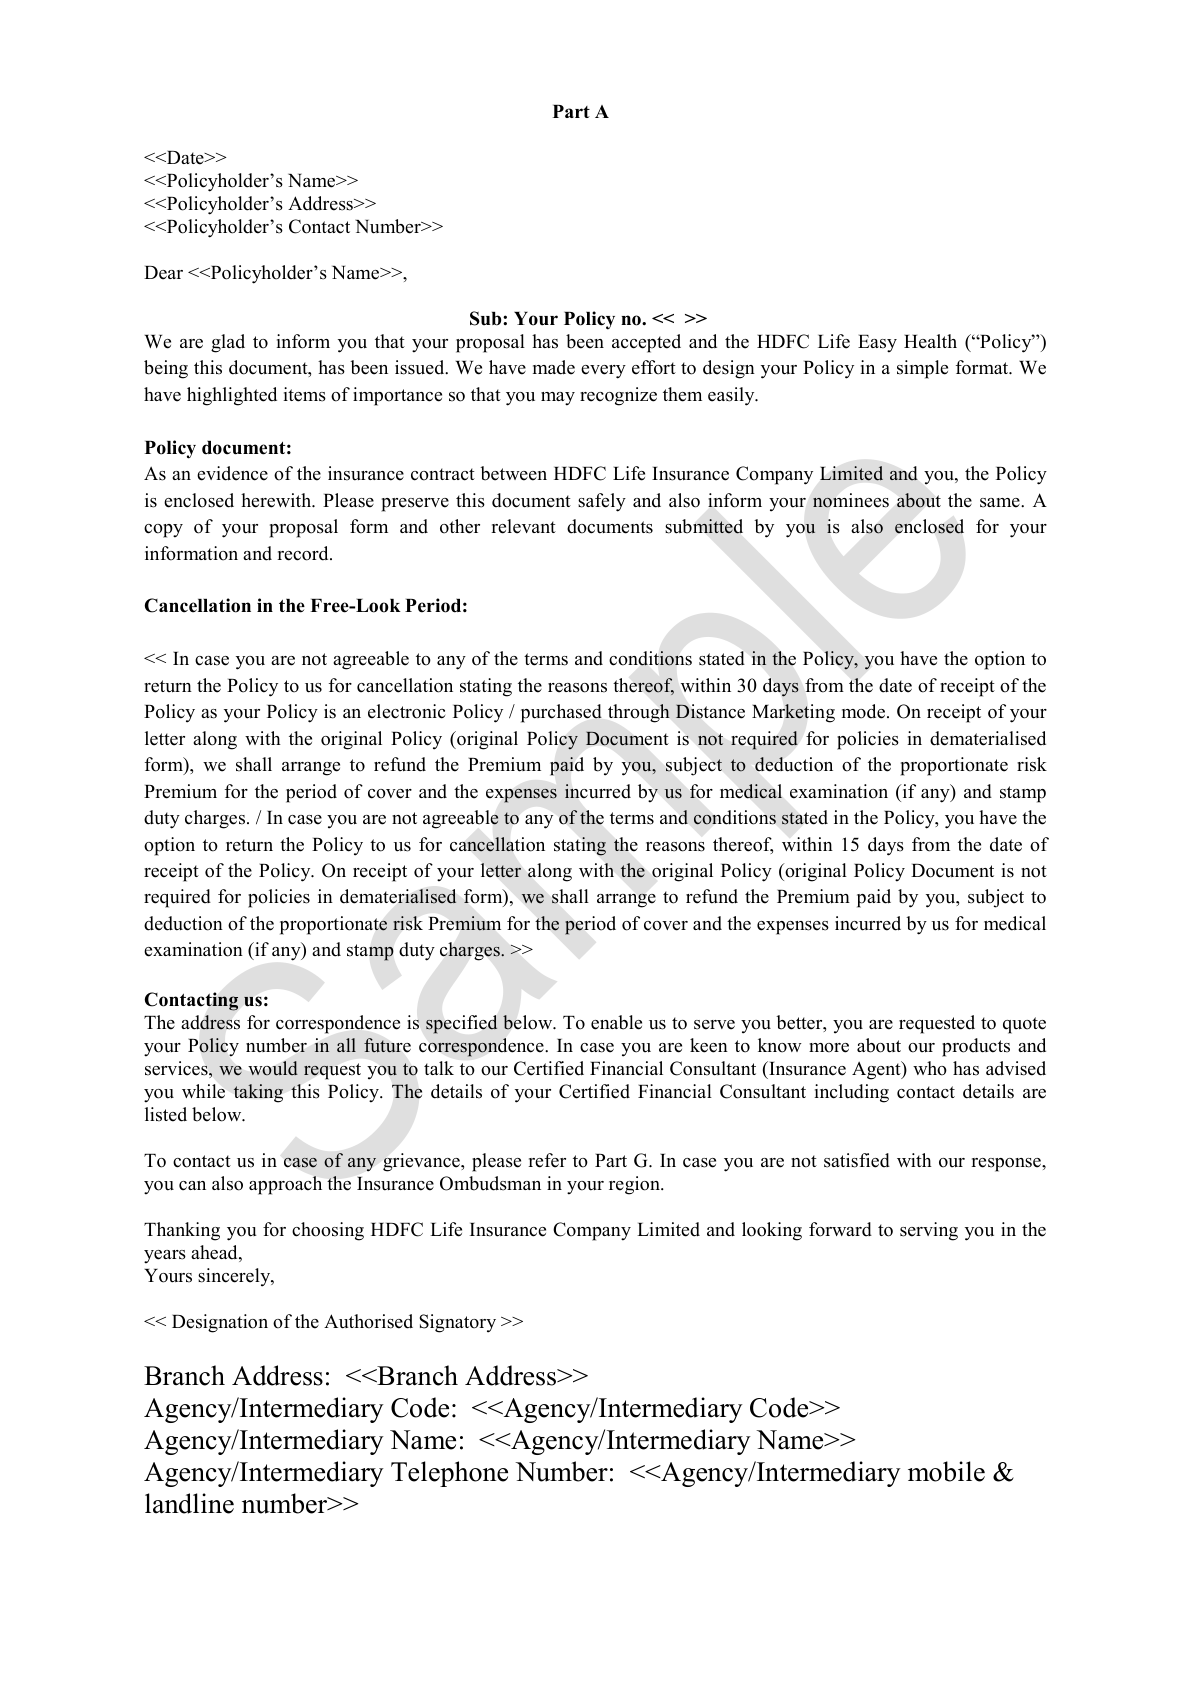

PosixPath('outputs/report_artifacts/preview_HDFC-Life-Easy-Health-101N110V03-Policy-Bond-Single-Pay_p1.png')

In [18]:
def preview_pdf_page(source_file: str, page_number_1based: int, zoom: float = 2.0):
    """
    Render a PDF page image for verification (optional).

    Requires PyMuPDF:
    - pip install pymupdf pillow

    Saves output into:
    - outputs/report_artifacts/preview_<file>_p<page>.png
    """
    if not HAVE_PYMUPDF:
        logger.warning("PyMuPDF not available. Install pymupdf to enable previews.")
        return None

    candidate = PDF_DIR_PRIMARY / source_file
    if not candidate.exists():
        candidate = PDF_DIR_FALLBACK / source_file
    if not candidate.exists():
        raise FileNotFoundError(f"PDF not found: {source_file}")

    import fitz
    from PIL import Image

    doc = fitz.open(str(candidate))
    page = doc.load_page(page_number_1based - 1)
    pix = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom))

    out_path = REPORT_DIR / f"preview_{Path(source_file).stem}_p{page_number_1based}.png"
    pix.save(str(out_path))
    doc.close()

    logger.info(f"✅ Saved preview: {out_path}")
    display(Image.open(out_path))
    return out_path

# Example:
preview_pdf_page(PDFS[0].name, 1)

# 11) 🧾 Flowchart Export (Report Artifact)

Generates:
- Mermaid flowchart: `outputs/report_artifacts/semantic_spotter_flowchart.mmd`
- Graphviz PNG (if available): `outputs/report_artifacts/semantic_spotter_flowchart.png`

---


In [19]:
def export_flowchart():
    """
    Export a system flowchart to Mermaid + Graphviz (if available).

    Mermaid is always generated.
    Graphviz PNG is generated only if graphviz Python package + system support exists.
    """
    mermaid = r"""
flowchart LR
    A[Policy PDFs] --> B[Line-by-line Extraction<br/>(coords + text)]
    B --> C[Structure Analysis<br/>Headers/Footers, TOC, Tables, Headings]
    C --> D[Cleaning<br/>Remove repetitive headers/footers]
    D --> E[Smart Chunking<br/>Section-aware + Definitions smaller]
    E --> F[Nodes + Metadata<br/>file, pages, section, type]
    F --> G[VectorStoreIndex<br/>(persistent)]
    F --> H[SummaryIndex]
    G --> I[Guarded Lookup Engine<br/>Top-K + Similarity cutoff]
    H --> J[Summary Engine]
    I --> K[RouterQueryEngine]
    J --> K
    K --> L[Answer + Citations]
    K --> M[Chunk Viewer + Inspector]
    C --> N[Evidence JSON Reports]
"""
    mmd_path = REPORT_DIR / "semantic_spotter_flowchart.mmd"
    mmd_path.write_text(mermaid.strip() + "\n", encoding="utf-8")
    logger.info(f"✅ Mermaid flowchart written: {mmd_path}")

    try:
        from graphviz import Digraph

        g = Digraph("SemanticSpotter", format="png")
        g.attr(rankdir="LR", fontsize="10")

        def node(k, label):
            g.node(k, label=label, shape="box", style="rounded,filled", fillcolor="#F6F8FA")

        node("A", "Policy PDFs")
        node("B", "Line-by-line Extraction\n(coords + text)")
        node("C", "Structure Analysis\nHeaders/Footers, TOC, Tables, Headings")
        node("D", "Cleaning\nRemove repetitive headers/footers")
        node("E", "Smart Chunking\nSection-aware + Definitions smaller")
        node("F", "Nodes + Metadata\nfile, pages, section, type")
        node("G", "VectorStoreIndex\n(persistent)")
        node("H", "SummaryIndex")
        node("I", "Guarded Lookup Engine\nTop-K + Similarity cutoff")
        node("J", "Summary Engine")
        node("K", "RouterQueryEngine")
        node("L", "Answer + Citations")
        node("M", "Chunk Viewer + Inspector")
        node("N", "Evidence JSON Reports")

        g.edges([("A","B"), ("B","C"), ("C","D"), ("D","E"), ("E","F")])
        g.edges([("F","G"), ("F","H"), ("G","I"), ("H","J"), ("I","K"), ("J","K"), ("K","L"), ("K","M"), ("C","N")])

        out_path = g.render(filename=str(REPORT_DIR / "semantic_spotter_flowchart"), cleanup=True)
        logger.info(f"✅ Graphviz flowchart rendered: {out_path}")
        return {"mermaid": str(mmd_path), "graphviz": out_path}

    except Exception as e:
        logger.warning("⚠️ Graphviz not available (Mermaid still generated).")
        logger.warning(f"Reason: {e}")
        return {"mermaid": str(mmd_path), "graphviz": None}

export_flowchart()

2025-12-18 08:54:50,827 | INFO | semantic_spotter | ✅ Mermaid flowchart written: outputs/report_artifacts/semantic_spotter_flowchart.mmd
2025-12-18 08:54:51,015 | INFO | semantic_spotter | ✅ Graphviz flowchart rendered: outputs/report_artifacts/semantic_spotter_flowchart.png


{'mermaid': 'outputs/report_artifacts/semantic_spotter_flowchart.mmd',
 'graphviz': 'outputs/report_artifacts/semantic_spotter_flowchart.png'}

# 12) ✅ Mini Evaluation Set

Purpose:
- verify retrieval quality
- verify citations
- verify guardrail behavior
- verify routing between lookup vs summary

---

In [20]:
EVAL_QUESTIONS = [
    "What is the free-look period and how can the policy be cancelled?",
    "Where are the definitions listed in the policy document?",
    "What does the policy schedule contain?",
    "What is the grace period (if mentioned) and where is it described?",
    "What are exclusions (if any) and where are they mentioned?",
    "Summarize the major parts/sections of this policy in 8-10 bullet points.",
]

for q in EVAL_QUESTIONS:
    ask(q)


════════════════════════════════════════════════════════════════════════════════════════════════════
❓ QUESTION: What is the free-look period and how can the policy be cancelled?
2025-12-18 08:54:52,295 | INFO | httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-12-18 08:54:52,297 | INFO | llama_index.core.query_engine.router_query_engine | Selecting query engine 0: The question specifically asks for factual information regarding the free-look period and policy cancellation, which aligns with the details provided in choice 1..
2025-12-18 08:54:52,657 | INFO | httpx | HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-12-18 08:54:55,049 | INFO | httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"

✅ ANSWER:

The free-look period is 15 days from the date of receipt of the policy document. If the policyholder disagrees with any of the terms and conditions, they can return the policy 

# 13) 📦 Submission Artifacts + Tuning

## Artifacts produced
- Evidence JSONs:
  - `outputs/pdf_analysis/<pdf>__analysis.json`
  - `outputs/pdf_analysis/ALL_PDFS__analysis_summary.json`
- Flowchart:
  - `outputs/report_artifacts/semantic_spotter_flowchart.mmd`
  - `outputs/report_artifacts/semantic_spotter_flowchart.png` (if graphviz available)
- Optional persisted index:
  - `storage_llamaindex/`

## Tuning tips
If too many “Not found”:
- reduce `SIMILARITY_CUTOFF` slowly (0.80 → 0.75 → 0.70)
- increase `TOP_K` (6 → 10)

If retrieval is noisy:
- increase `SIMILARITY_CUTOFF` (0.80 → 0.85)
- reduce `TOP_K`

✅ End of notebook.

In [26]:
# ✅ Single-cell generator (NO triple-quoted f-strings): Word Report + README + requirements + ZIP

from __future__ import annotations

import re, json, sys, zipfile, subprocess
from dataclasses import dataclass
from datetime import date
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

# -----------------------------
# Install deps (only if missing)
# -----------------------------
def _pip_install(pkgs: List[str]) -> None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

try:
    import docx  # noqa
except Exception:
    _pip_install(["python-docx>=1.1.2"])

from docx import Document
from docx.enum.style import WD_STYLE_TYPE
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import qn
from docx.shared import Inches, Pt

# -----------------------------
# Locate artifacts (Colab/Jupyter safe)
# -----------------------------
SEARCH_DIRS = [Path(".").resolve(), Path("/content"), Path("/mnt/data")]
SEARCH_DIRS = [p for p in SEARCH_DIRS if p.exists()]

def find_first_existing(paths: List[Path]) -> Optional[Path]:
    for p in paths:
        if p and p.exists():
            return p
    return None

def find_in_dirs(relpath: str) -> Optional[Path]:
    return find_first_existing([d / relpath for d in SEARCH_DIRS])

analysis_summary_path = find_first_existing([
    find_in_dirs("outputs/pdf_analysis/ALL_PDFS__analysis_summary.json"),
    find_in_dirs("ALL_PDFS__analysis_summary.json"),
])

flowchart_png_path = find_first_existing([
    find_in_dirs("outputs/report_artifacts/semantic_spotter_flowchart.png"),
    find_in_dirs("semantic_spotter_flowchart.png"),
])

sample_page_png_path = find_first_existing([
    find_in_dirs("preview_HDFC-Life-Easy-Health-101N110V03-Policy-Bond-Single-Pay_p1.png"),
])

project_py_path = find_first_existing([
    find_in_dirs("Sematic_Spotter_RAG_Project_Nikesh_v2.py"),
])

out_dir = Path("submission_artifacts").resolve()
out_dir.mkdir(parents=True, exist_ok=True)

print("✅ Detected artifacts:")
print(" - analysis summary:", analysis_summary_path)
print(" - flowchart png   :", flowchart_png_path)
print(" - sample page png :", sample_page_png_path)
print(" - project py      :", project_py_path)
print(" - output dir      :", out_dir)

# -----------------------------
# Config extraction (best-effort)
# -----------------------------
DEFAULT_CONFIG: Dict[str, Any] = {
    "OUT_DIR": "outputs/pdf_analysis",
    "PERSIST_DIR": "storage_llamaindex",
    "REPORT_DIR": "outputs/report_artifacts",
    "REPEAT_FRACTION": 0.70,
    "TOP_BAND_FRAC": 0.12,
    "BOT_BAND_FRAC": 0.12,
    "TOC_SCAN_PAGES": 10,
    "DEFAULT_TARGET_CHARS": 2400,
    "DEFAULT_OVERLAP_CHARS": 300,
    "DEFN_TARGET_CHARS": 1400,
    "DEFN_OVERLAP_CHARS": 220,
    "TOP_K": 6,
    "SIMILARITY_CUTOFF": 0.80,
}

def parse_uppercase_assignments(py_text: str) -> Dict[str, Any]:
    cfg: Dict[str, Any] = {}
    pattern = re.compile(r'^\s*([A-Z_][A-Z0-9_]*)\s*=\s*(.+?)\s*(?:#.*)?$', re.M)
    for m in pattern.finditer(py_text):
        k, raw = m.group(1), m.group(2).strip().rstrip(",")
        if k.startswith("__"):
            continue
        if raw.startswith(("'", '"')) and raw.endswith(("'", '"')):
            cfg[k] = raw.strip("'\"")
        elif raw in ("True", "False"):
            cfg[k] = (raw == "True")
        else:
            try:
                cfg[k] = float(raw) if "." in raw else int(raw)
            except Exception:
                cfg[k] = raw
    return cfg

CONFIG = dict(DEFAULT_CONFIG)
if project_py_path and project_py_path.exists():
    txt = project_py_path.read_text(encoding="utf-8", errors="ignore")
    CONFIG.update(parse_uppercase_assignments(txt))

print("\n✅ Effective config used in report:")
for k in ["OUT_DIR", "PERSIST_DIR", "REPORT_DIR", "TOP_K", "SIMILARITY_CUTOFF", "DEFAULT_TARGET_CHARS", "DEFN_TARGET_CHARS"]:
    print(f" - {k}: {CONFIG.get(k)}")

# -----------------------------
# Load analysis summary (optional)
# -----------------------------
@dataclass
class PdfReport:
    pdf: str
    pages: int
    toc_pages: List[int]
    table_pages_count: int
    strategy: str
    general_chars: str
    defn_chars: str

def load_reports(summary_path: Optional[Path]) -> List[PdfReport]:
    if not summary_path or not summary_path.exists():
        return []
    raw = json.loads(summary_path.read_text(encoding="utf-8"))
    if not isinstance(raw, list):
        return []
    reports: List[PdfReport] = []
    for it in raw:
        if not isinstance(it, dict):
            continue
        toc_pages = it.get("toc_pages") if isinstance(it.get("toc_pages"), list) else []
        toc_pages_int: List[int] = []
        for p in toc_pages:
            try:
                toc_pages_int.append(int(p))
            except Exception:
                pass
        table_pages = it.get("table_pages") if isinstance(it.get("table_pages"), list) else []
        table_count = sum(1 for t in table_pages if isinstance(t, dict) and "page" in t)
        rc = it.get("recommended_chunking") if isinstance(it.get("recommended_chunking"), dict) else {}
        reports.append(PdfReport(
            pdf=str(it.get("pdf", "")),
            pages=int(it.get("pages", 0) or 0),
            toc_pages=toc_pages_int,
            table_pages_count=table_count,
            strategy=str(rc.get("strategy", "-")),
            general_chars=str(rc.get("target_chars_general", "-")),
            defn_chars=str(rc.get("target_chars_definitions", "-")),
        ))
    return reports

REPORTS = load_reports(analysis_summary_path)

# -----------------------------
# Word helpers
# -----------------------------
def ensure_code_style(doc: Document) -> None:
    styles = doc.styles
    if "CodeBlock" in [s.name for s in styles]:
        return
    style = styles.add_style("CodeBlock", WD_STYLE_TYPE.PARAGRAPH)
    style.font.name = "Consolas"
    style._element.rPr.rFonts.set(qn("w:eastAsia"), "Consolas")
    style.font.size = Pt(9)

def add_title(doc: Document, title: str, subtitle: str) -> None:
    p = doc.add_paragraph()
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    r = p.add_run(title); r.bold = True; r.font.size = Pt(22)

    p2 = doc.add_paragraph()
    p2.alignment = WD_ALIGN_PARAGRAPH.CENTER
    r2 = p2.add_run(subtitle); r2.font.size = Pt(12)

    p3 = doc.add_paragraph()
    p3.alignment = WD_ALIGN_PARAGRAPH.CENTER
    r3 = p3.add_run(f"Date: {date.today().isoformat()}"); r3.font.size = Pt(10)

    doc.add_page_break()

def safe_set_table_style(table, style_name: str) -> None:
    try:
        table.style = style_name
    except Exception:
        pass

def add_data_sources_table(doc: Document, reports: List[PdfReport]) -> None:
    doc.add_heading("Data Sources", level=1)
    doc.add_paragraph("The project ingests insurance policy PDFs and builds evidence-backed retrieval over clauses, definitions, schedules, and exclusions.")
    if not reports:
        doc.add_paragraph("ALL_PDFS__analysis_summary.json not found or empty (table omitted).")
        return

    table = doc.add_table(rows=1, cols=7)
    safe_set_table_style(table, "Light Shading Accent 1")
    hdr = table.rows[0].cells
    hdr[0].text, hdr[1].text, hdr[2].text = "PDF", "Pages", "TOC pages"
    hdr[3].text, hdr[4].text = "Tables (count)", "Chunk strategy"
    hdr[5].text, hdr[6].text = "General chars", "Definitions chars"

    for r in reports:
        row = table.add_row().cells
        row[0].text = r.pdf
        row[1].text = str(r.pages)
        row[2].text = ", ".join(map(str, r.toc_pages)) if r.toc_pages else "-"
        row[3].text = str(r.table_pages_count)
        row[4].text = r.strategy
        row[5].text = r.general_chars
        row[6].text = r.defn_chars

def add_flowchart(doc: Document, flowchart_png: Optional[Path]) -> None:
    doc.add_heading("System Design Flowchart", level=1)
    doc.add_paragraph("Pipeline: PDF ingestion → structure analysis → cleaning → smart chunking → indexing → guarded retrieval → routing → answer with citations + inspector.")
    if flowchart_png and flowchart_png.exists():
        doc.add_picture(str(flowchart_png), width=Inches(6.9))
    else:
        doc.add_paragraph("Flowchart PNG not found (expected semantic_spotter_flowchart.png).")

def add_architecture(doc: Document) -> None:
    doc.add_heading("Architecture and Design Choices", level=1)
    doc.add_heading("Layer 1 — PDF Ingestion and Extraction", level=2)
    doc.add_paragraph("Extracts text line-by-line with layout signals to handle policy formatting and section structure.")
    doc.add_heading("Layer 2 — Structure Analysis + Cleaning", level=2)
    doc.add_paragraph("Detects TOC/headings/tables and removes repetitive headers/footers to reduce embedding noise.")
    doc.add_heading("Layer 3 — Smart Chunking", level=2)
    doc.add_paragraph("Section-aware chunking; smaller chunks for Definitions to improve term lookup precision.")
    doc.add_heading("Layer 4 — Indexing", level=2)
    doc.add_paragraph("Builds a persistent VectorStoreIndex for semantic lookup; SummaryIndex for overviews when LLM is enabled.")
    doc.add_heading("Layer 5 — Guarded Retrieval + Routing", level=2)
    doc.add_paragraph("Top-K retrieval + similarity cutoff; if nothing qualifies, returns 'Not found in documents' to prevent hallucinations.")
    doc.add_heading("Layer 6 — Answer + Citations + Inspector", level=2)
    doc.add_paragraph("Returns answers with citations from node metadata; inspector exposes raw hits and scores for debugging.")

def add_config(doc: Document, cfg: Dict[str, Any]) -> None:
    doc.add_heading("Key Configuration", level=1)
    ensure_code_style(doc)
    code = "\n".join([
        f"OUT_DIR = {cfg.get('OUT_DIR')!r}",
        f"PERSIST_DIR = {cfg.get('PERSIST_DIR')!r}",
        f"REPORT_DIR = {cfg.get('REPORT_DIR')!r}",
        "",
        f"DEFAULT_TARGET_CHARS = {cfg.get('DEFAULT_TARGET_CHARS')}",
        f"DEFAULT_OVERLAP_CHARS = {cfg.get('DEFAULT_OVERLAP_CHARS')}",
        f"DEFN_TARGET_CHARS = {cfg.get('DEFN_TARGET_CHARS')}",
        f"DEFN_OVERLAP_CHARS = {cfg.get('DEFN_OVERLAP_CHARS')}",
        "",
        f"TOP_K = {cfg.get('TOP_K')}",
        f"SIMILARITY_CUTOFF = {cfg.get('SIMILARITY_CUTOFF')}",
    ])
    doc.add_paragraph(code, style="CodeBlock")

def add_challenges(doc: Document) -> None:
    doc.add_heading("Challenges Faced and Mitigations", level=1)
    items = [
        ("Repetitive headers/footers", "Detected by repetition thresholds and removed to avoid indexing boilerplate."),
        ("Tables & schedules", "Captured as table chunks to preserve structure and improve factual lookup."),
        ("Definitions precision", "Definitions chunked smaller than general sections to reduce retrieval ambiguity."),
        ("Hallucination risk", "Guarded retrieval returns 'Not found in documents' if evidence doesn’t meet cutoff."),
        ("PDF variability", "Adaptive chunking recommendations derived from layout/indent patterns."),
        ("Debuggability", "Inspector tooling to view candidate chunks, scores, and filtered results."),
    ]
    for t, d in items:
        p = doc.add_paragraph()
        p.add_run(f"{t}: ").bold = True
        p.add_run(d)

def add_run_steps(doc: Document, cfg: Dict[str, Any]) -> None:
    doc.add_heading("README Summary — How to Run", level=1)
    steps = [
        "Install dependencies using requirements.txt.",
        "Place PDFs in data/pdfs/ (recommended) or make them accessible in the runtime.",
        f"Run the main script to generate evidence JSONs in: {cfg.get('OUT_DIR')}",
        f"Index persistence directory: {cfg.get('PERSIST_DIR')}",
        f"Flowchart artifacts directory: {cfg.get('REPORT_DIR')}",
        "Use ask(query) for answers + citations; inspect_query(query) for retrieval debugging.",
    ]
    for s in steps:
        doc.add_paragraph(s, style="List Bullet")

# -----------------------------
# Generate Word Report
# -----------------------------
docx_path = out_dir / "Semantic_Spotter_Project_Report.docx"
doc = Document()

add_title(doc,
          "Semantic Spotter — Semantic Search & RAG over Policy PDFs",
          "Comprehensive Documentation (LlamaIndex)")

doc.add_heading("Project Goals", level=1)
doc.add_paragraph(
    "Build an evidence-backed semantic spotter system over insurance policy PDFs using LlamaIndex. "
    "The system answers policy questions with citations, supports high-level summaries (when an LLM is available), "
    "and applies guardrails to avoid hallucinations when evidence is insufficient."
)

add_data_sources_table(doc, REPORTS)
add_flowchart(doc, flowchart_png_path)

doc.add_heading("Sample Policy Page (Optional)", level=1)
doc.add_paragraph("Example showing structured sections/placeholders typical in policy documents.")
if sample_page_png_path and sample_page_png_path.exists():
    doc.add_picture(str(sample_page_png_path), width=Inches(6.6))
else:
    doc.add_paragraph("Sample page image not found (optional).")

add_architecture(doc)
add_config(doc, CONFIG)
add_challenges(doc)
add_run_steps(doc, CONFIG)

doc.add_paragraph()
endp = doc.add_paragraph("— End of report —")
endp.alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.save(str(docx_path))
print(f"\n✅ Word report saved: {docx_path}")

# -----------------------------
# Generate README + requirements (NO triple-quotes)
# -----------------------------
readme_path = out_dir / "README.md"
requirements_path = out_dir / "requirements.txt"

readme_lines = [
    "# Semantic Spotter (LlamaIndex RAG)",
    "",
    "A semantic search + RAG pipeline over insurance policy PDFs using **LlamaIndex**.",
    "",
    "## Deliverables",
    "- Word report: `Semantic_Spotter_Project_Report.docx`",
    "- System flowchart: `semantic_spotter_flowchart.png` (embedded in report if available)",
    f"- Evidence JSONs: `{CONFIG.get('OUT_DIR')}/...`",
    "",
    "## Key configuration",
    f"- TOP_K: {CONFIG.get('TOP_K')}",
    f"- SIMILARITY_CUTOFF: {CONFIG.get('SIMILARITY_CUTOFF')}",
    f"- OUT_DIR: {CONFIG.get('OUT_DIR')}",
    f"- PERSIST_DIR: {CONFIG.get('PERSIST_DIR')}",
    f"- REPORT_DIR: {CONFIG.get('REPORT_DIR')}",
    "",
    "## Setup",
    "```bash",
    "python -m venv .venv",
    "source .venv/bin/activate  # Windows: .venv\\Scripts\\activate",
    "pip install -r requirements.txt",
    "```",
    "",
    "## Run",
    "```bash",
    "python Sematic_Spotter_RAG_Project_Nikesh_v2.py",
    "```",
    "",
    "## Outputs",
    f"- Evidence JSONs: `{CONFIG.get('OUT_DIR')}/<pdf>__analysis.json` and `{CONFIG.get('OUT_DIR')}/ALL_PDFS__analysis_summary.json`",
    f"- Persisted index: `{CONFIG.get('PERSIST_DIR')}/`",
    f"- Flowchart artifacts: `{CONFIG.get('REPORT_DIR')}/semantic_spotter_flowchart.*`",
    "",
    "## Tuning",
    "- If too many “Not found”: lower `SIMILARITY_CUTOFF` or increase `TOP_K`.",
    "- If retrieval is noisy: raise `SIMILARITY_CUTOFF` or reduce `TOP_K`.",
    "",
]
readme_text = "\n".join(readme_lines)

requirements_text = "\n".join([
    "python-docx>=1.1.2",
    "llama-index>=0.10.0",
    "sentence-transformers>=2.2.2",
    "transformers>=4.40.0",
    "torch>=2.1.0",
    "pymupdf>=1.23.0",
    "pillow>=10.0.0",
    "numpy>=1.24.0",
    "pandas>=2.0.0",
    "tqdm>=4.66.0",
    "",
])

readme_path.write_text(readme_text, encoding="utf-8")
requirements_path.write_text(requirements_text, encoding="utf-8")
print(f"✅ README saved: {readme_path}")
print(f"✅ requirements saved: {requirements_path}")

# -----------------------------
# Zip everything
# -----------------------------
zip_path = out_dir / "submission_artifacts.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    z.write(docx_path, arcname=docx_path.name)
    z.write(readme_path, arcname=readme_path.name)
    z.write(requirements_path, arcname=requirements_path.name)

    # Extras
    if flowchart_png_path and flowchart_png_path.exists():
        z.write(flowchart_png_path, arcname=f"extras/{flowchart_png_path.name}")
    if sample_page_png_path and sample_page_png_path.exists():
        z.write(sample_page_png_path, arcname=f"extras/{sample_page_png_path.name}")
    if analysis_summary_path and analysis_summary_path.exists():
        z.write(analysis_summary_path, arcname=f"extras/{analysis_summary_path.name}")

print(f"✅ ZIP saved: {zip_path}")

print("\n📦 Output files:")
for p in sorted(out_dir.glob("*")):
    print(" -", p.name, f"({p.stat().st_size} bytes)")

✅ Detected artifacts:
 - analysis summary: /content/outputs/pdf_analysis/ALL_PDFS__analysis_summary.json
 - flowchart png   : /content/outputs/report_artifacts/semantic_spotter_flowchart.png
 - sample page png : None
 - project py      : None
 - output dir      : /content/submission_artifacts

✅ Effective config used in report:
 - OUT_DIR: outputs/pdf_analysis
 - PERSIST_DIR: storage_llamaindex
 - REPORT_DIR: outputs/report_artifacts
 - TOP_K: 6
 - SIMILARITY_CUTOFF: 0.8
 - DEFAULT_TARGET_CHARS: 2400
 - DEFN_TARGET_CHARS: 1400

✅ Word report saved: /content/submission_artifacts/Semantic_Spotter_Project_Report.docx
✅ README saved: /content/submission_artifacts/README.md
✅ requirements saved: /content/submission_artifacts/requirements.txt
✅ ZIP saved: /content/submission_artifacts/submission_artifacts.zip

📦 Output files:
 - README.md (1101 bytes)
 - Semantic_Spotter_Project_Report.docx (104830 bytes)
 - requirements.txt (174 bytes)
 - submission_artifacts.zip (181018 bytes)
